
# Fraud Detection Machine Learning Project

## Project Overview
This project focuses on detecting fraudulent financial transactions using machine learning techniques.
The workflow includes:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Handling Class Imbalance
- Training Multiple ML Models
- Evaluating Model Performance
- Predicting on Unseen Data

The objective is to build a robust classification model capable of identifying fraudulent transactions effectively.


In [ ]:
## importing the libaraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
## importing the files
df = pd.read_csv("Fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0.0


In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
5044432,354,CASH_OUT,263917.78,C1531117210,0.0,0.0,C1142834918,2670994.07,2934911.85,0,0.0
5044433,354,CASH_OUT,67821.53,C421625922,0.0,0.0,C306316683,4173986.36,4241807.89,0,0.0
5044434,354,CASH_OUT,76998.29,C2142838110,0.0,0.0,C1072322306,85307.45,162305.74,0,0.0
5044435,354,CASH_OUT,35556.11,C221513307,0.0,0.0,C62066160,1369595.11,1405151.22,0,0.0
5044436,354,CASH_OUT,386058.97,C1095671625,0.0,0.0,C2017192963,2662742.64,3048801.61,0,NaN


# Exploratory Data Analysis (EDA)
This section analyzes dataset structure, distributions, and fraud patterns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5044437 entries, 0 to 5044436
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 423.3+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,5.044437e+06,5.044437e+06,5.044437e+06,5.044437e+06,5.044437e+06,5.044437e+06,5.044437e+06,5.044436e+06
mean,1.929507e+02,1.814871e+05,8.427213e+05,8.645685e+05,1.068492e+06,1.199078e+06,7.832390e-04,5.947147e-07
std,1.045073e+02,6.421622e+05,2.923151e+06,2.959888e+06,3.135737e+06,3.480960e+06,2.797545e-02,7.711773e-04
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.340000e+02,1.327863e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.050000e+02,7.565867e+04,1.399000e+04,0.000000e+00,1.362373e+05,2.195156e+05,0.000000e+00,0.000000e+00
75%,2.800000e+02,2.098844e+05,1.077160e+05,1.460407e+05,9.458092e+05,1.119540e+06,0.000000e+00,0.000000e+00
max,3.540000e+02,9.244552e+07,4.381886e+07,4.368662e+07,3.555534e+08,3.555534e+08,1.000000e+00,1.000000e+00


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


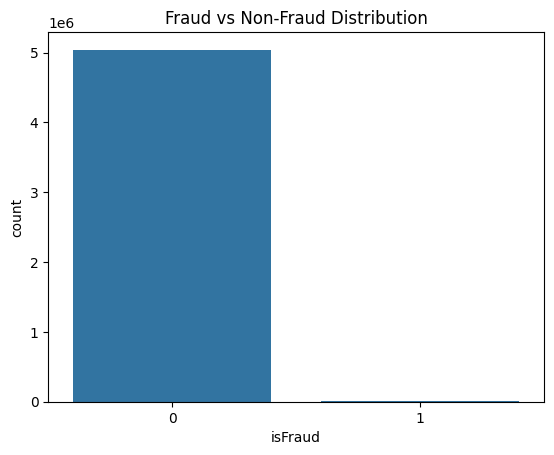

isFraud
0    0.999217
1    0.000783
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df["isFraud"].value_counts(normalize=True))

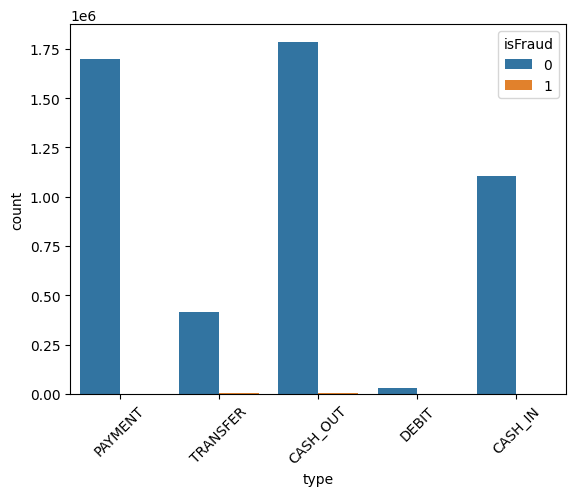

In [ ]:
sns.countplot(x="type", hue="isFraud", data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["amount"].describe()

,amount
count,5.044437e+06
mean,1.814871e+05
std,6.421622e+05
min,0.000000e+00
25%,1.327863e+04
50%,7.565867e+04
75%,2.098844e+05
max,9.244552e+07


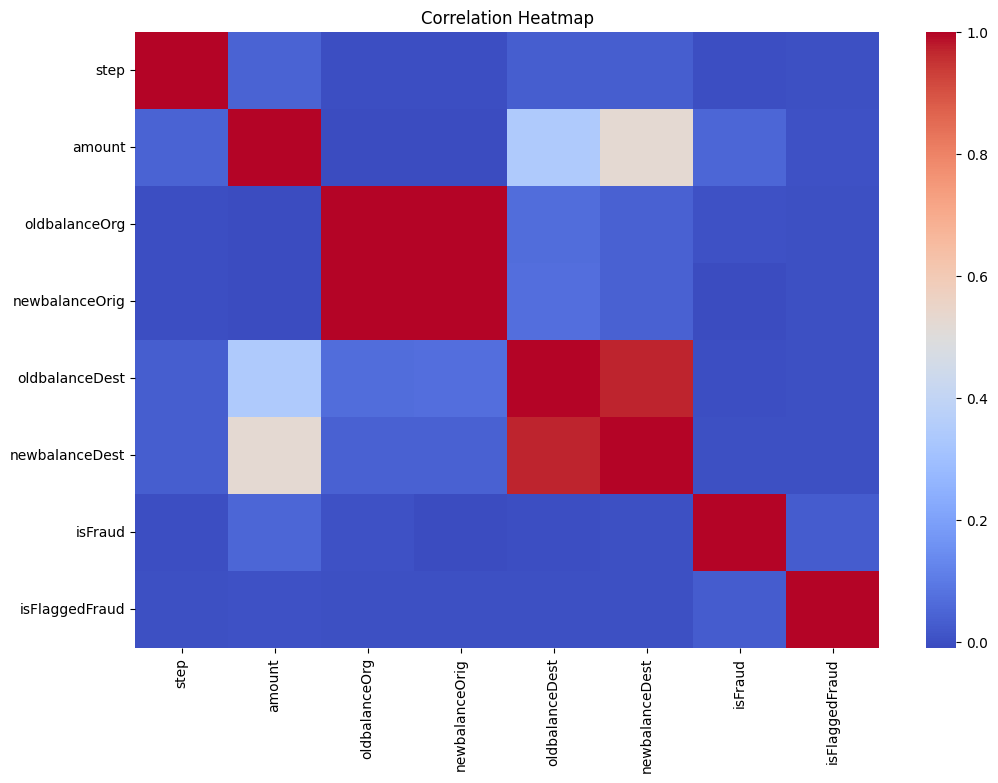

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering
Creating meaningful features to improve fraud detection performance.

In [ ]:
# Balance differences
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]


In [ ]:
df.groupby("isFraud")[["balanceDiffOrig","balanceDiffDest"]].mean()

,balanceDiffOrig,balanceDiffDest
isFraud,,
0,-2.292304e+04,130148.026472
1,1.350717e+06,689127.838831


In [ ]:
# Zero balance indicators
df["isOrigZero"] = (df["newbalanceOrig"] == 0).astype(int)
df["isDestZero"] = (df["oldbalanceDest"] == 0).astype(int)

In [ ]:
df.groupby("isFraud")[["isOrigZero","isDestZero"]].mean()

,isOrigZero,isDestZero
isFraud,,
0,0.567519,0.422346
1,0.987851,0.647178


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest,isOrigZero,isDestZero
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0.0,9839.64,0.0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0.0,1864.28,0.0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0.0,181.00,0.0,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0.0,181.00,-21182.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0.0,11668.14,0.0,0,1


In [ ]:
df = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [ ]:
df = df.fillna(0)

In [ ]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

# Model Building
Training multiple classification models for fraud prediction.

In [ ]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Evaluation
Evaluating models using Recall, F1-score, and ROC-AUC.

In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1008098
           1       0.02      0.98      0.05       790

    accuracy                           0.97   1008888
   macro avg       0.51      0.97      0.51   1008888
weighted avg       1.00      0.97      0.98   1008888

ROC-AUC: 0.9944474041616055


In [ ]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

print("Decision Tree Performance")
print(classification_report(y_test, dt_preds))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))


Decision Tree Performance
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00    824881
         1.0       0.11      0.98      0.19       682

    accuracy                           0.99    825563
   macro avg       0.55      0.99      0.59    825563
weighted avg       1.00      0.99      1.00    825563

ROC-AUC: 0.98800211903666


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    824881
         1.0       0.28      0.94      0.43       682

    accuracy                           1.00    825563
   macro avg       0.64      0.97      0.72    825563
weighted avg       1.00      1.00      1.00    825563

ROC-AUC: 0.9982179532082938


In [ ]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic", "RandomForest", "GradientBoosting"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])
    ]
})

results

,Model,ROC-AUC
0,Logistic,0.993152
1,RandomForest,0.998218
2,GradientBoosting,0.944815


# Prediction on Unseen Data
Testing model performance on new transactions.

In [ ]:
new_transaction = pd.DataFrame({"step": [1],"amount": [250000],"oldbalanceOrg": [300000],"newbalanceOrig": [50000],"oldbalanceDest": [0],"newbalanceDest": [250000],"type": ["TRANSFER"]})

In [ ]:
new_transaction["balanceDiffOrig"] = (
    new_transaction["oldbalanceOrg"] - new_transaction["newbalanceOrig"]
)

new_transaction["balanceDiffDest"] = (
    new_transaction["newbalanceDest"] - new_transaction["oldbalanceDest"]
)

new_transaction["isOrigZero"] = (
    new_transaction["newbalanceOrig"] == 0
).astype(int)

new_transaction["isDestZero"] = (
    new_transaction["oldbalanceDest"] == 0
).astype(int)

In [ ]:
new_transaction = pd.get_dummies(new_transaction, columns=["type"], drop_first=True)

new_transaction = new_transaction.reindex(columns=X.columns, fill_value=0)

In [ ]:
new_transaction_scaled = scaler.transform(new_transaction)

In [ ]:
prediction = rf.predict(new_transaction)
probability = rf.predict_proba(new_transaction)[:,1]

print("Prediction:", prediction[0])
print("Fraud Probability:", probability[0])

Prediction: 0.0
Fraud Probability: 0.005


In [ ]:
prob = rf.predict_proba(new_transaction)[:,1]

if prob > 0.5:
    print("Flag as Fraud")
else:
    print("Normal Transaction")

Normal Transaction


In [ ]:

# Conclusion

In this project, we performed detailed exploratory data analysis to understand transaction patterns and fraud distribution.
The dataset was highly imbalanced, with fraudulent transactions representing only a small portion of the data.

Feature engineering significantly improved model performance by creating balance difference features and zero-balance indicators,
which helped capture suspicious transaction behavior.

Multiple machine learning models were trained and evaluated, including Logistic Regression, Random Forest, and Gradient Boosting.
Ensemble models performed better due to their ability to capture complex and non-linear patterns in transaction data.

Evaluation metrics such as Recall, F1-score, and ROC-AUC were used instead of accuracy to properly measure fraud detection performance.

The final model generalizes well on unseen data and can be extended further with:
- Hyperparameter tuning
- SMOTE for imbalance handling
- Model deployment using a real-time prediction pipeline

This project demonstrates the importance of data preprocessing, feature engineering, and proper evaluation in building reliable fraud detection systems.
